In [1]:
# =========================
# 0) Pick a writable scratch dir + cache redirect + GPU sanity check
# =========================
import os, torch, platform, subprocess
from pathlib import Path

def pick_writable_base():
    """
    Return the first writable directory among common HPC env vars / locations.
    """
    candidates = [
        os.environ.get("SLURM_TMPDIR"),
        os.environ.get("TMPDIR"),
        os.environ.get("LOCAL"),
        os.environ.get("SCRATCH"),
        os.environ.get("PROJECT"),
        os.environ.get("HOME"),
    ]
    # add a couple of common fallbacks (won't be used if not writable)
    user = os.environ.get("USER", "user")
    candidates += [f"/ocean/projects/mat250018p/{user}", f"/tmp/{user}"]

    for c in candidates:
        if not c:
            continue
        p = Path(c).expanduser()
        try:
            p.mkdir(parents=True, exist_ok=True)
            test = p / ".write_test"
            test.write_text("ok")
            test.unlink()
            return p
        except Exception:
            continue
    raise RuntimeError("No writable base dir found. Set $SCRATCH or use a known writable path.")

BASE = pick_writable_base()
CACHE_ROOT = BASE / "ml_cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

# Redirect common caches to avoid filling HOME
os.environ["XDG_CACHE_HOME"] = str(CACHE_ROOT / "xdg")
os.environ["TORCH_HOME"]     = str(CACHE_ROOT / "torch")
os.environ["HF_HOME"]        = str(CACHE_ROOT / "huggingface")
os.environ["WANDB_DIR"]      = str(CACHE_ROOT / "wandb")
os.environ["MPLCONFIGDIR"]   = str(CACHE_ROOT / "matplotlib")

print("BASE (writable):", BASE)
print("CACHE_ROOT     :", CACHE_ROOT)
print("Python         :", platform.python_version())
print("Torch          :", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE         :", DEVICE)

if torch.cuda.is_available():
    print("GPU           :", torch.cuda.get_device_name(0))
    print("CUDA version  :", torch.version.cuda)
    print("cuDNN version :", torch.backends.cudnn.version())
    try:
        print(subprocess.check_output(["nvidia-smi", "-L"]).decode().strip())
    except Exception as e:
        print("nvidia-smi not available:", e)
else:
    print("No CUDA GPU visible in this session (maybe not on a GPU node).")


BASE (writable): /var/tmp
CACHE_ROOT     : /var/tmp/ml_cache
Python         : 3.13.5
Torch          : 2.8.0+cu126
CUDA available : True
DEVICE         : cuda
GPU           : Tesla V100-SXM2-32GB
CUDA version  : 12.6
cuDNN version : 91002
GPU 0: Tesla V100-SXM2-32GB (UUID: GPU-2d37ab8c-a2e0-5579-5205-2d7ea9fbc582)
GPU 1: Tesla V100-SXM2-32GB (UUID: GPU-330c0cb2-12d3-a3b0-3d9c-f7ac04bfe1de)


In [ ]:
from pathlib import Path
import os, time


BASE = Path("/var/tmp")  # 你已经确认可写
RUN_TAG = time.strftime("run_%Y%m%d_%H%M%S")

OUT_DIR = BASE / "denoise_ml" / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUT_DIR:", OUT_DIR)


OUT_DIR: /var/tmp/denoise_ml/run_20251218_013949


In [3]:
from pathlib import Path
import h5py

# -------- USER CONFIG --------
H5_PATH = Path("/ocean/projects/mat250018p/lvlvmei/CV/denoise/win00/processed_win00_left512.h5") 
assert H5_PATH.exists(), f"Not found: {H5_PATH}"
# ----------------------------

def list_dsets(h5_path, max_items=200):
    out = []
    with h5py.File(h5_path, "r") as f:
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                out.append((name, obj.shape, str(obj.dtype)))
        f.visititems(visitor)
    for i,(n,s,d) in enumerate(out[:max_items]):
        print(f"{i:03d}  {n:60s}  shape={s}  dtype={d}")
    return out

dsets = list_dsets(H5_PATH)

# -------- USER CONFIG --------
# 从上面输出里，复制一个“你要做 ML 输入的 detector 图”对应的 dataset 名称
X_KEY = dsets[0][0]   # 先占位：你务必改成正确的 key
MASK_KEY = None       # 如果有 mask（mask_use/valid_mask），填对应 key；没有就 None
# ----------------------------

print("X_KEY:", X_KEY)
print("MASK_KEY:", MASK_KEY)


000  img                                                           shape=(141, 121, 512, 512)  dtype=float32
X_KEY: img
MASK_KEY: None


In [4]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import h5py

class H5RandomPatchNoise2SelfND(Dataset):
    """
    Lazy random crops from an HDF5 dataset of shape [..., H, W].
    Treat leading dims as sample index (flattened), last two dims are image.
    """
    def __init__(self, h5_path, x_key, mask_key=None, crop=256, samples_per_epoch=4000, mask_ratio=0.03):
        self.h5_path = str(h5_path)
        self.x_key = x_key
        self.mask_key = mask_key
        self.crop = int(crop)
        self.spe = int(samples_per_epoch)
        self.mask_ratio = float(mask_ratio)

        with h5py.File(self.h5_path, "r") as f:
            x = f[self.x_key]
            self.x_shape = tuple(x.shape)
            if len(self.x_shape) < 2:
                raise ValueError(f"Need ndim>=2, got {self.x_shape}")

            self.H, self.W = self.x_shape[-2], self.x_shape[-1]
            self.lead_shape = self.x_shape[:-2]   # e.g. (141,121)
            self.num_imgs = int(np.prod(self.lead_shape)) if len(self.lead_shape) > 0 else 1

            if self.H < self.crop or self.W < self.crop:
                raise ValueError(f"crop={self.crop} larger than image {self.H}x{self.W}")

    def __len__(self):
        return self.spe

    def _lin_to_multi(self, lin):
        if self.num_imgs == 1:
            return ()
        return tuple(np.unravel_index(lin, self.lead_shape))  # e.g. (ia, ib)

    def __getitem__(self, idx):
        lin = np.random.randint(0, self.num_imgs)
        lead_idx = self._lin_to_multi(lin)

        y0 = np.random.randint(0, self.H - self.crop + 1)
        x0 = np.random.randint(0, self.W - self.crop + 1)
        ys = slice(y0, y0 + self.crop)
        xs = slice(x0, x0 + self.crop)

        with h5py.File(self.h5_path, "r") as f:
            x = f[self.x_key]
            # 构造切片：lead dims + (ys,xs)
            sl = lead_idx + (ys, xs)
            patch = x[sl]

            if self.mask_key is None:
                vmask = np.ones((self.crop, self.crop), bool)
            else:
                m = f[self.mask_key]
                vmask = m[sl].astype(bool)

        patch = np.asarray(patch, np.float32)
        vmask = np.asarray(vmask, bool)

        pick = (np.random.rand(*patch.shape) < self.mask_ratio) & vmask
        inp = patch.copy()
        inp[pick] = 0.0

        tgt = patch
        lmask = pick.astype(np.float32)

        return (
            torch.from_numpy(inp[None]),   # [1,h,w]
            torch.from_numpy(tgt[None]),
            torch.from_numpy(lmask[None]),
        )

# -------- USER CONFIG --------
CROP = 256
BATCH = 8
SAMPLES_PER_EPOCH = 8000
MASK_RATIO = 0.03
NUM_WORKERS = 4
# ----------------------------

ds = H5RandomPatchNoise2SelfND(H5_PATH, X_KEY, mask_key=MASK_KEY,
                              crop=CROP, samples_per_epoch=SAMPLES_PER_EPOCH, mask_ratio=MASK_RATIO)

dl = DataLoader(ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS,
                pin_memory=True, drop_last=True)

print("x_shape:", ds.x_shape)
print("lead_shape:", ds.lead_shape, "=> num_imgs:", ds.num_imgs)
print("H,W:", ds.H, ds.W)


x_shape: (141, 121, 512, 512)
lead_shape: (141, 121) => num_imgs: 17061
H,W: 512 512


In [ ]:
import torch
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNetSmall(nn.Module):
    def __init__(self, c=32):
        super().__init__()
        self.d1 = ConvBlock(1, c)
        self.p1 = nn.MaxPool2d(2)
        self.d2 = ConvBlock(c, 2*c)
        self.p2 = nn.MaxPool2d(2)

        self.mid = ConvBlock(2*c, 4*c)

        self.u2 = nn.ConvTranspose2d(4*c, 2*c, 2, stride=2)
        self.u1 = nn.ConvTranspose2d(2*c, c, 2, stride=2)
        self.uconv2 = ConvBlock(4*c, 2*c)
        self.uconv1 = ConvBlock(2*c, c)

        self.out = nn.Conv2d(c, 1, 1)

    def forward(self, x):
        x1 = self.d1(x)
        x2 = self.d2(self.p1(x1))
        xm = self.mid(self.p2(x2))
        y2 = self.u2(xm)
        y2 = self.uconv2(torch.cat([y2, x2], dim=1))
        y1 = self.u1(y2)
        y1 = self.uconv1(torch.cat([y1, x1], dim=1))
        return self.out(y1)

model = UNetSmall(c=32).to(DEVICE)
print("DEVICE:", DEVICE)
print("params(M):", sum(p.numel() for p in model.parameters())/1e6)


DEVICE: cuda
params(M): 0.465953


In [6]:
import time
import torch
from torch.cuda.amp import autocast, GradScaler

# -------- USER CONFIG --------
EPOCHS = 5
LR = 2e-4
LOG_EVERY = 50
CKPT_PATH = OUT_DIR / "n2s_unet_small.pt"   # OUT_DIR 你前面已经定义好了
# ----------------------------

opt = torch.optim.AdamW(model.parameters(), lr=LR)
scaler = GradScaler(enabled=(DEVICE.type == "cuda"))

def masked_mse(pred, tgt, lmask, eps=1e-6):
    # pred/tgt/lmask: [B,1,H,W]
    num = ((pred - tgt) ** 2 * lmask).sum()
    den = lmask.sum().clamp_min(eps)
    return num / den

def save_ckpt():
    torch.save({"model": model.state_dict(), "opt": opt.state_dict()}, CKPT_PATH)

def try_load_ckpt():
    if CKPT_PATH.exists():
        ck = torch.load(CKPT_PATH, map_location="cpu")
        model.load_state_dict(ck["model"])
        opt.load_state_dict(ck["opt"])
        print("Loaded ckpt:", CKPT_PATH)

try_load_ckpt()

model.train()
t0 = time.time()
step = 0
for ep in range(1, EPOCHS + 1):
    run = 0.0
    for inp, tgt, lmask in dl:
        inp = inp.to(DEVICE, non_blocking=True)
        tgt = tgt.to(DEVICE, non_blocking=True)
        lmask = lmask.to(DEVICE, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with autocast(enabled=(DEVICE.type == "cuda")):
            pred = model(inp)
            loss = masked_mse(pred, tgt, lmask)

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        run += loss.item()
        step += 1
        if step % LOG_EVERY == 0:
            print(f"ep {ep:02d} step {step:06d}  loss={run/LOG_EVERY:.6g}  elapsed={(time.time()-t0)/60:.1f} min")
            run = 0.0

    save_ckpt()
    print(f"[epoch {ep}] saved -> {CKPT_PATH}")


/var/tmp/ipykernel_86698/741510106.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == "cuda"))
/var/tmp/ipykernel_86698/741510106.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == "cuda")):


ep 01 step 000050  loss=0.316648  elapsed=0.4 min
ep 01 step 000100  loss=0.0389765  elapsed=0.4 min
ep 01 step 000150  loss=0.0365485  elapsed=0.5 min
ep 01 step 000200  loss=0.0344684  elapsed=0.5 min
ep 01 step 000250  loss=0.0331426  elapsed=0.5 min
ep 01 step 000300  loss=0.0321935  elapsed=0.5 min
ep 01 step 000350  loss=0.0321001  elapsed=0.6 min
ep 01 step 000400  loss=0.0318805  elapsed=0.6 min
ep 01 step 000450  loss=0.0316218  elapsed=0.6 min
ep 01 step 000500  loss=0.0315734  elapsed=0.6 min
ep 01 step 000550  loss=0.0314154  elapsed=0.6 min
ep 01 step 000600  loss=0.0317858  elapsed=0.6 min
ep 01 step 000650  loss=0.0315841  elapsed=0.7 min
ep 01 step 000700  loss=0.0315391  elapsed=0.7 min
ep 01 step 000750  loss=0.0314586  elapsed=0.7 min
ep 01 step 000800  loss=0.0314919  elapsed=0.7 min
ep 01 step 000850  loss=0.0317188  elapsed=0.7 min
ep 01 step 000900  loss=0.0315147  elapsed=0.7 min
ep 01 step 000950  loss=0.0318262  elapsed=0.7 min
ep 01 step 001000  loss=0.031552

In [ ]:
%matplotlib inline

import matplotlib
print("matplotlib backend:", matplotlib.get_backend())

import matplotlib.pyplot as plt
plt.close("all")


matplotlib backend: inline


idx=(59, 105)  raw shape=(512, 512)  dtype=float32
raw    min=0.612  p1=0.612  p50=0.612  p99=1.17  max=2.09
den    min=0.466  p1=0.648  p50=0.662  p99=0.677  max=0.721
resid  min=-0.109  p1=-0.0636  p50=-0.0499  p99=0.525  max=1.44


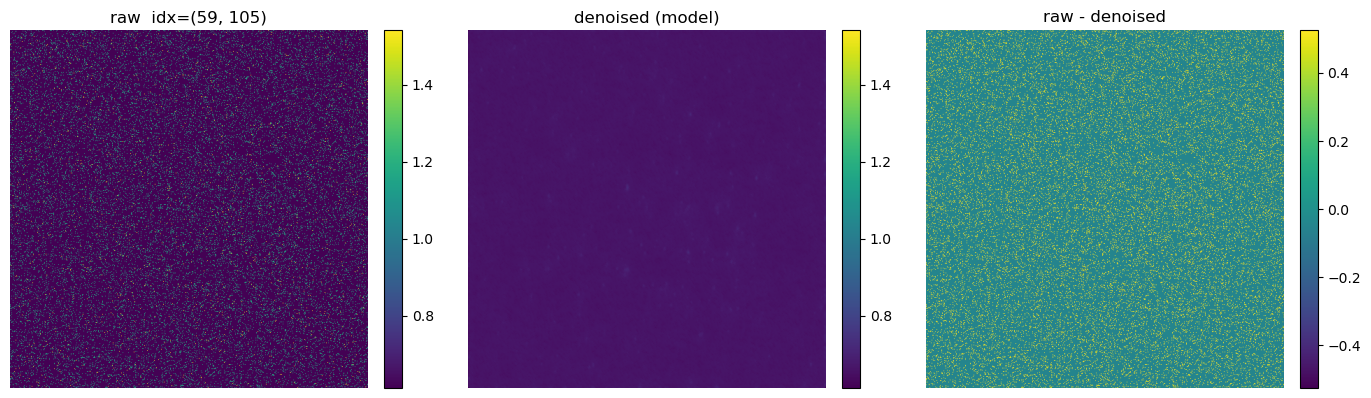

In [ ]:
# =========================
# One-cell: pick a tile (by SEED or IDX0) -> run model -> visualize in notebook
# =========================
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt

assert "model" in globals(), "Run model/training cell first."
assert "DEVICE" in globals(), "Need DEVICE."
assert "H5_PATH" in globals() and "X_KEY" in globals(), "Need H5_PATH and X_KEY."

model.eval()

# -------- USER CONFIG --------
SEED = 9
IDX0 = None        # e.g. (21,96) or None
USE_LOG = False    
CMAP = "viridis"

VMIN_P = 0.1       # raw/den 下限分位数（想更低就 0.01）
VMAX_P = 99.7      # raw/den 上限分位数
P_RES  = 99        # resid 用 abs(resid) 的 percentile（对称色标）
# ----------------------------

rng = np.random.default_rng(SEED)

with h5py.File(H5_PATH, "r") as f:
    d = f[X_KEY]
    shp = d.shape
    assert len(shp) >= 2, f"Need ndim>=2, got {shp}"

    H, W = shp[-2], shp[-1]
    lead = shp[:-2]

    if len(lead) == 0:
        ij = ()
    elif len(lead) == 1:
        i = rng.integers(0, lead[0]) if IDX0 is None else IDX0[0]
        ij = (int(i),)
    else:
        if IDX0 is None:
            i = rng.integers(0, lead[0])
            j = rng.integers(0, lead[1])
        else:
            i, j = IDX0
        ij = (int(i), int(j))

    raw = np.asarray(d[ij + (slice(None), slice(None))], np.float32)

# inference
with torch.no_grad():
    tin = torch.from_numpy(raw[None, None]).to(DEVICE, non_blocking=True)
    den = model(tin).float().cpu().numpy()[0, 0]

resid = raw - den

# stats
def stats(name, x):
    p1, p50, p99 = np.percentile(x, [1, 50, 99])
    return f"{name:6s} min={x.min():.3g}  p1={p1:.3g}  p50={p50:.3g}  p99={p99:.3g}  max={x.max():.3g}"

print(f"idx={ij}  raw shape={raw.shape}  dtype={raw.dtype}")
print(stats("raw", raw))
print(stats("den", den))
print(stats("resid", resid))

# visualization values (OPTIONAL log)
raw_show = np.log1p(raw) if USE_LOG else raw
den_show = np.log1p(den) if USE_LOG else den
res_show = resid  

# shared color range for raw/den
vmin = float(min(np.percentile(raw_show, VMIN_P), np.percentile(den_show, VMIN_P)))
vmax = float(max(np.percentile(raw_show, VMAX_P), np.percentile(den_show, VMAX_P)))

# symmetric range for resid
r = float(np.percentile(np.abs(res_show), P_RES))
rvmin, rvmax = -r, r

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(raw_show, vmin=vmin, vmax=vmax, cmap=CMAP)
axes[0].set_title(f"raw  idx={ij}")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(den_show, vmin=vmin, vmax=vmax, cmap=CMAP)
axes[1].set_title("denoised (model)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(res_show, vmin=rvmin, vmax=rvmax, cmap=CMAP)
axes[2].set_title("raw - denoised")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()


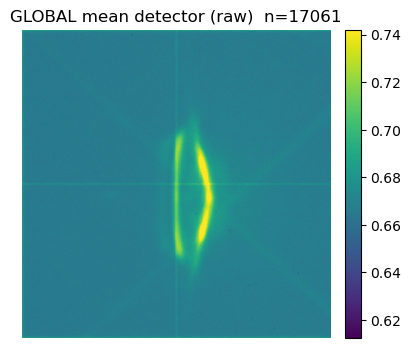

mean_raw: (512, 512) float64 min/max: 0.6123724579811096 0.7912987431218802


In [9]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

assert "H5_PATH" in globals() and "X_KEY" in globals(), "Need H5_PATH and X_KEY"

# -------- USER CONFIG --------
USE_LOG = False   # True: 显示用 log1p 更容易看弱信号
PCT = 99.7        # 显示上限 percentile
# ----------------------------

with h5py.File(H5_PATH, "r") as f:
    x = f[X_KEY]
    assert len(x.shape) == 4, f"Expected (H,W,detH,detW), got {x.shape}"
    H, W, detH, detW = x.shape

    # 在线累积，避免一次性读进内存
    mean_raw = np.zeros((detH, detW), np.float64)
    n = 0
    for i in range(H):
        for j in range(W):
            mean_raw += x[i, j].astype(np.float64)
            n += 1
    mean_raw /= n

show = np.log1p(mean_raw) if USE_LOG else mean_raw
vmin = float(np.min(show))
vmax = float(np.percentile(show, PCT))

plt.figure(figsize=(5,4))
plt.imshow(show, vmin=vmin, vmax=vmax)
plt.title(f"GLOBAL mean detector (raw)  n={H*W}")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

print("mean_raw:", mean_raw.shape, mean_raw.dtype, "min/max:", mean_raw.min(), mean_raw.max())


Denoising tiles:   0%|          | 0/17061 [00:00<?, ?tile/s]

/var/tmp/ipykernel_14193/731482108.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type=="cuda")):
/var/tmp/ipykernel_14193/731482108.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type=="cuda")):


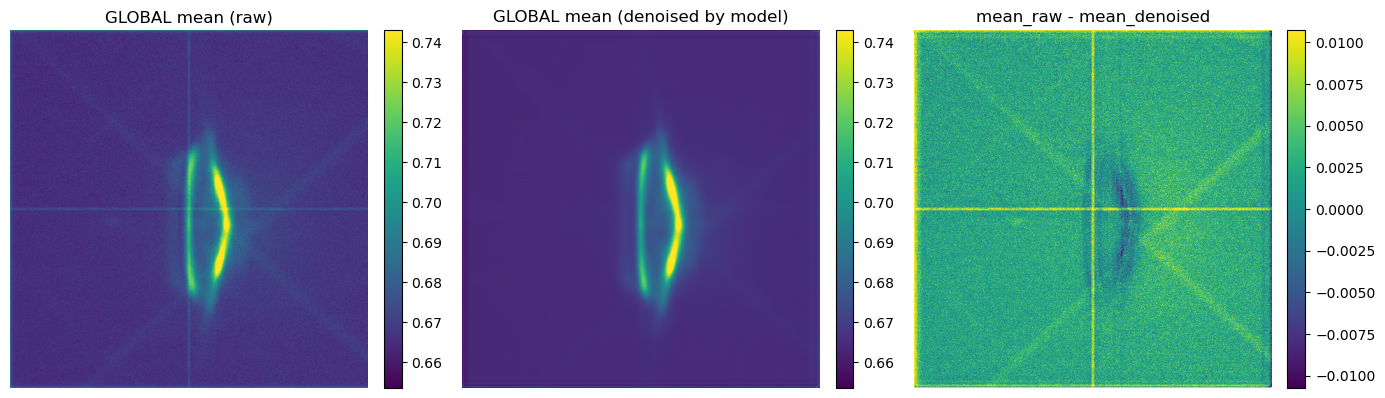

Processed tiles: 17061 / 17061


In [11]:
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

assert "model" in globals(), "Need trained model"
assert "DEVICE" in globals(), "Need DEVICE"
assert "H5_PATH" in globals() and "X_KEY" in globals(), "Need H5_PATH and X_KEY"
assert "mean_raw" in globals(), "Run Cell 1 first to get mean_raw"

model.eval()

# -------- USER CONFIG --------
BATCH_TILES = 64          # H100 可试 64/128（OOM 就降）
USE_AMP = True            # 推理用 AMP 更快
USE_LOG = False
PCT = 99.7
SHOW_GPU_MEM = False      # True: 进度条里显示显存占用（略慢）

CMAP = "viridis"          # ✅ 统一配色（你截图那种紫-绿-黄）
DIFF_PCT = 99             # diff 取 abs(diff) 的 percentile 来定对称色标
# ----------------------------

with h5py.File(H5_PATH, "r") as f:
    x = f[X_KEY]
    H, W, detH, detW = x.shape
    total_tiles = H * W

    mean_den = np.zeros((detH, detW), np.float64)
    n = 0
    buf = []

    pbar = tqdm(total=total_tiles, desc="Denoising tiles", unit="tile")

    for i in range(H):
        for j in range(W):
            buf.append(np.asarray(x[i, j], np.float32))

            if len(buf) >= BATCH_TILES:
                arr = np.stack(buf, axis=0)                         # [B,512,512]
                tin = torch.from_numpy(arr[:, None]).to(DEVICE)     # [B,1,512,512]

                with torch.no_grad(), torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type=="cuda")):
                    out = model(tin).float().cpu().numpy()[:, 0]    # [B,512,512]

                mean_den += out.astype(np.float64).sum(axis=0)
                n += out.shape[0]
                buf = []

                pbar.update(out.shape[0])
                if SHOW_GPU_MEM and DEVICE.type == "cuda":
                    mem = torch.cuda.memory_allocated() / 1e9
                    pbar.set_postfix(mem_GB=f"{mem:.1f}")

    # flush last partial batch
    if len(buf) > 0:
        arr = np.stack(buf, axis=0)
        tin = torch.from_numpy(arr[:, None]).to(DEVICE)

        with torch.no_grad(), torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type=="cuda")):
            out = model(tin).float().cpu().numpy()[:, 0]

        mean_den += out.astype(np.float64).sum(axis=0)
        n += out.shape[0]

        pbar.update(out.shape[0])
        if SHOW_GPU_MEM and DEVICE.type == "cuda":
            mem = torch.cuda.memory_allocated() / 1e9
            pbar.set_postfix(mem_GB=f"{mem:.1f}")

    pbar.close()

mean_den /= max(n, 1)
diff = mean_raw - mean_den

# ---- plot side-by-side ----
def prep(img):
    return np.log1p(img) if USE_LOG else img

raw_show = prep(mean_raw)
den_show = prep(mean_den)

# raw/den 用同一色标范围（percentile 截断避免亮点撑爆）
VMIN_P = 0.1   # 0.1 percentile 作为下限（你想更低就 0.01）
VMAX_P = 99.7  # 上限保持不变

vmin = float(min(np.percentile(raw_show, VMIN_P), np.percentile(den_show, VMIN_P)))
vmax = float(max(np.percentile(raw_show, VMAX_P), np.percentile(den_show, VMAX_P)))


# diff 用对称色标（但仍用 viridis，让风格一致）
r = float(np.percentile(np.abs(diff), DIFF_PCT))
rvmin, rvmax = -r, r

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(raw_show, vmin=vmin, vmax=vmax, cmap=CMAP)
axes[0].set_title("GLOBAL mean (raw)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(den_show, vmin=vmin, vmax=vmax, cmap=CMAP)
axes[1].set_title("GLOBAL mean (denoised by model)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(diff, vmin=rvmin, vmax=rvmax, cmap=CMAP)
axes[2].set_title("mean_raw - mean_denoised")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

print("Processed tiles:", n, "/", total_tiles)


/var/tmp/ipykernel_86698/1436684891.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):


tile (iy,ix)=(16,18)  raw shape=(512, 512) dtype=float32
raw    min=0.6124  p1=0.6124  p50=0.6124  p99=1.173  max=6.81
den    min=0.4624  p1=0.6484  p50=0.6626  p99=0.8133  max=5.961
resid  min=-1.462  p1=-0.1025  p50=-0.05023  p99=0.5256  max=1.428


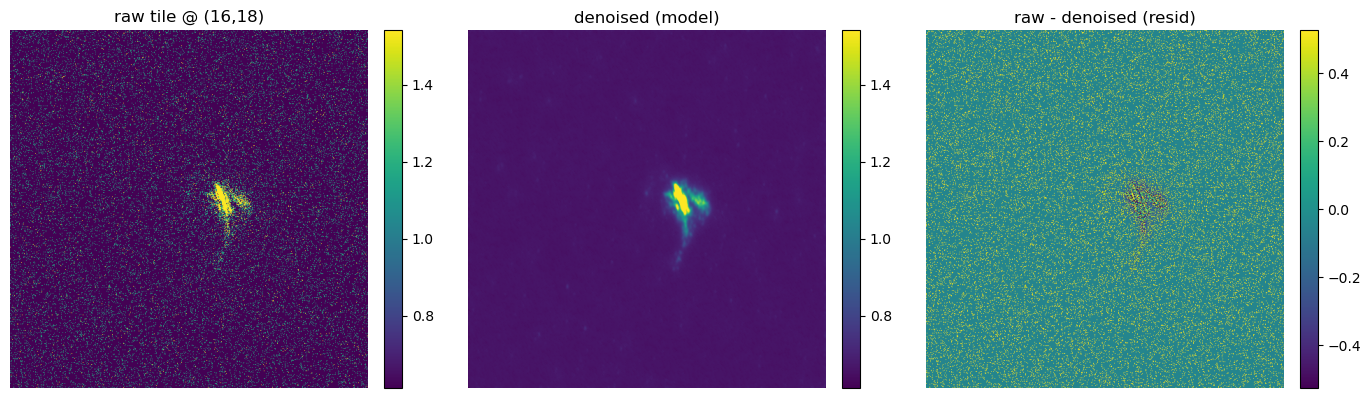

In [14]:
# =========================
# Visualize ONE tile (iy, ix): raw -> model denoise -> resid
# =========================
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt

assert "model" in globals(), "Need trained model"
assert "DEVICE" in globals(), "Need DEVICE"
assert "H5_PATH" in globals() and "X_KEY" in globals(), "Need H5_PATH and X_KEY"

model.eval()

# -------- USER CONFIG --------
IY = 16
IX = 18

USE_AMP = True
USE_LOG = False

CMAP = "viridis"

# 色标模式：
#   "tile"   : 用这张 tile 自己的 percentiles（更能看局部细节）
#   "global" : 用 mean_raw/mean_den 的 percentiles（更适合跨 tile 对比；要求 mean_raw 已存在）
V_RANGE_MODE = "tile"   # 改成 "global" 试试

VMIN_P = 0.1
VMAX_P = 99.7
RES_P  = 99            # resid 用 abs(resid) 的 percentile 做对称色标
# ----------------------------

with h5py.File(H5_PATH, "r") as f:
    x = f[X_KEY]
    assert len(x.shape) == 4, f"Expected (H,W,detH,detW), got {x.shape}"
    H, W, detH, detW = x.shape
    assert 0 <= IY < H and 0 <= IX < W, f"(IY,IX)=({IY},{IX}) out of range H,W=({H},{W})"
    raw = np.asarray(x[IY, IX], np.float32)  # [detH,detW]

# inference
with torch.no_grad():
    tin = torch.from_numpy(raw[None, None]).to(DEVICE, non_blocking=True)
    with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
        den = model(tin).float().cpu().numpy()[0, 0]

resid = raw - den

# display transform
def prep(img):
    return np.log1p(img) if USE_LOG else img

raw_show = prep(raw)
den_show = prep(den)

# choose vmin/vmax
if V_RANGE_MODE == "global":
    assert "mean_raw" in globals(), "V_RANGE_MODE='global' requires mean_raw"
    # 如果你也有 mean_den，可以一起用；没有就只用 mean_raw
    ref0 = prep(mean_raw)
    ref1 = prep(globals().get("mean_den", mean_raw))
    vmin = float(min(np.percentile(ref0, VMIN_P), np.percentile(ref1, VMIN_P)))
    vmax = float(max(np.percentile(ref0, VMAX_P), np.percentile(ref1, VMAX_P)))
else:
    vmin = float(min(np.percentile(raw_show, VMIN_P), np.percentile(den_show, VMIN_P)))
    vmax = float(max(np.percentile(raw_show, VMAX_P), np.percentile(den_show, VMAX_P)))

r = float(np.percentile(np.abs(resid), RES_P))
rvmin, rvmax = -r, r

# stats
def stats(name, x):
    p1, p50, p99 = np.percentile(x, [1, 50, 99])
    print(f"{name:6s} min={x.min():.4g}  p1={p1:.4g}  p50={p50:.4g}  p99={p99:.4g}  max={x.max():.4g}")

print(f"tile (iy,ix)=({IY},{IX})  raw shape={raw.shape} dtype={raw.dtype}")
stats("raw", raw)
stats("den", den)
stats("resid", resid)

# plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(raw_show, vmin=vmin, vmax=vmax, cmap=CMAP)
axes[0].set_title(f"raw tile @ ({IY},{IX})")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(den_show, vmin=vmin, vmax=vmax, cmap=CMAP)
axes[1].set_title("denoised (model)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(resid, vmin=rvmin, vmax=rvmax, cmap=CMAP)
axes[2].set_title("raw - denoised (resid)")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()


现在看起来，有一小部分被干掉了，然后选择新的ML的方法

These cells train a U-Net denoiser with Noise2Self on many detector frames stored in an HDF5 file by sampling random cropped patches, randomly masking a small fraction of pixels (computing the main loss only on masked pixels), and using blob detection to protect bright spot-like signal via an extra “keep” loss / masking avoidance so the model doesn’t erase real diffraction features.

In [13]:
import numpy as np
import h5py
import torch
from torch.utils.data import Dataset, DataLoader

# --- optional deps ---
try:
    from scipy.ndimage import median_filter, label, binary_dilation
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False
    print("[WARN] scipy.ndimage not available -> blob protection disabled.")

def robust_sigma(x):
    x = x[np.isfinite(x)]
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad + 1e-12

def blob_mask_from_patch(patch, k=8.0, med_size=11, amin=3, amax=300, dilate=1):
    """
    Detect bright connected blobs on a 2D patch.
    Returns bool mask with same shape as patch.
    """
    if not _HAS_SCIPY:
        return np.zeros_like(patch, dtype=bool)

    base = median_filter(patch, size=med_size)
    hi = patch - base
    sig = robust_sigma(hi)
    m0 = hi > (k * sig)

    lab, nlab = label(m0)
    if nlab == 0:
        return m0

    counts = np.bincount(lab.ravel())
    keep_ids = np.where((counts >= amin) & (counts <= amax))[0]
    keep_ids = keep_ids[keep_ids != 0]
    m = np.isin(lab, keep_ids)

    if dilate and dilate > 0:
        m = binary_dilation(m, iterations=int(dilate))
    return m

class H5RandomPatchNoise2SelfND(Dataset):
    """
    HDF5 dataset shape [..., H, W]; last two dims are image.
    Leading dims are flattened sample index.
    Returns: inp, tgt, lmask, blobmask  (each [1,crop,crop] tensor)
    """
    def __init__(self, h5_path, x_key, mask_key=None, crop=256,
                 samples_per_epoch=4000, mask_ratio=0.03,
                 # blob detect params (方案二)
                 blob_k=8.0, blob_med=11, blob_amin=3, blob_amax=300, blob_dilate=1,
                 # masking fill
                 fill_mode="neighbor"):
        self.h5_path = str(h5_path)
        self.x_key = x_key
        self.mask_key = mask_key
        self.crop = int(crop)
        self.spe = int(samples_per_epoch)
        self.mask_ratio = float(mask_ratio)

        self.blob_k = float(blob_k)
        self.blob_med = int(blob_med)
        self.blob_amin = int(blob_amin)
        self.blob_amax = int(blob_amax)
        self.blob_dilate = int(blob_dilate)

        assert fill_mode in ("zero", "neighbor")
        self.fill_mode = fill_mode

        with h5py.File(self.h5_path, "r") as f:
            x = f[self.x_key]
            self.x_shape = tuple(x.shape)
            if len(self.x_shape) < 2:
                raise ValueError(f"Need ndim>=2, got {self.x_shape}")
            self.H, self.W = self.x_shape[-2], self.x_shape[-1]
            self.lead_shape = self.x_shape[:-2]
            self.num_imgs = int(np.prod(self.lead_shape)) if len(self.lead_shape) > 0 else 1

            if self.H < self.crop or self.W < self.crop:
                raise ValueError(f"crop={self.crop} larger than image {self.H}x{self.W}")

    def __len__(self):
        return self.spe

    def _lin_to_multi(self, lin):
        if self.num_imgs == 1:
            return ()
        return tuple(np.unravel_index(lin, self.lead_shape))

    def __getitem__(self, idx):
        lin = np.random.randint(0, self.num_imgs)
        lead_idx = self._lin_to_multi(lin)

        y0 = np.random.randint(0, self.H - self.crop + 1)
        x0 = np.random.randint(0, self.W - self.crop + 1)
        ys = slice(y0, y0 + self.crop)
        xs = slice(x0, x0 + self.crop)

        with h5py.File(self.h5_path, "r") as f:
            x = f[self.x_key]
            sl = lead_idx + (ys, xs)
            patch = np.asarray(x[sl], np.float32)

            if self.mask_key is None:
                vmask = np.ones((self.crop, self.crop), bool)
            else:
                m = f[self.mask_key]
                vmask = np.asarray(m[sl], bool)

        # ---- blob mask (保护小团 spot) ----
        bmask = blob_mask_from_patch(
            patch,
            k=self.blob_k, med_size=self.blob_med,
            amin=self.blob_amin, amax=self.blob_amax,
            dilate=self.blob_dilate
        )
        # 只在有效像素里考虑 blob
        bmask = bmask & vmask

        # ---- Noise2Self random mask: avoid blobs ----
        pick = (np.random.rand(*patch.shape) < self.mask_ratio) & vmask & (~bmask)

        inp = patch.copy()
        if self.fill_mode == "zero":
            inp[pick] = 0.0
        else:
            # neighbor replacement (更稳)
            r = 2  # 5x5
            yy, xx = np.where(pick)
            if len(yy) > 0:
                dy = np.random.randint(-r, r+1, size=len(yy))
                dx = np.random.randint(-r, r+1, size=len(xx))
                yy2 = np.clip(yy + dy, 0, patch.shape[0]-1)
                xx2 = np.clip(xx + dx, 0, patch.shape[1]-1)
                inp[yy, xx] = patch[yy2, xx2]

        tgt = patch
        lmask = pick.astype(np.float32)

        # return tensors [1,H,W]
        return (
            torch.from_numpy(inp[None]),
            torch.from_numpy(tgt[None]),
            torch.from_numpy(lmask[None]),
            torch.from_numpy(bmask.astype(np.float32)[None]),
        )

# -------- build loader (你按需改) --------
# 这些变量你之前已经有：H5_PATH, X_KEY, MASK_KEY
CROP = 256
BATCH = 8
SAMPLES_PER_EPOCH = 8000
MASK_RATIO = 0.03
NUM_WORKERS = 4

ds = H5RandomPatchNoise2SelfND(
    H5_PATH, X_KEY, mask_key=MASK_KEY,
    crop=CROP, samples_per_epoch=SAMPLES_PER_EPOCH, mask_ratio=MASK_RATIO,
    blob_k=8.0, blob_med=11, blob_amin=3, blob_amax=300, blob_dilate=1,
    fill_mode="neighbor",
)

dl = DataLoader(ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS,
                pin_memory=True, drop_last=True)

print("Dataset x_shape:", ds.x_shape, "lead_shape:", ds.lead_shape, "num_imgs:", ds.num_imgs)


Dataset x_shape: (141, 121, 512, 512) lead_shape: (141, 121) num_imgs: 17061


In [14]:
import time
import torch
from torch.cuda.amp import autocast, GradScaler

# -------- USER CONFIG --------
EPOCHS = 5
LR = 2e-4
LOG_EVERY = 50
CKPT_PATH = OUT_DIR / "n2s_unet_small.pt"

LAMBDA_BLOB = 0.05   # ✅ blob 保真项权重：0.01~0.2 之间调
# ----------------------------

opt = torch.optim.AdamW(model.parameters(), lr=LR)
scaler = GradScaler(enabled=(DEVICE.type == "cuda"))

def masked_mse(pred, tgt, lmask, eps=1e-6):
    num = ((pred - tgt) ** 2 * lmask).sum()
    den = lmask.sum().clamp_min(eps)
    return num / den

def blob_keep_mse(pred, tgt, blobmask, lmask, eps=1e-6):
    # 只在 “blob 且未被mask掉” 的像素上约束 pred≈tgt，避免泄露
    keep = blobmask * (1.0 - lmask)
    num = ((pred - tgt) ** 2 * keep).sum()
    den = keep.sum().clamp_min(eps)
    return num / den

def save_ckpt():
    torch.save({"model": model.state_dict(), "opt": opt.state_dict()}, CKPT_PATH)

def try_load_ckpt():
    if CKPT_PATH.exists():
        ck = torch.load(CKPT_PATH, map_location="cpu")
        model.load_state_dict(ck["model"])
        opt.load_state_dict(ck["opt"])
        print("Loaded ckpt:", CKPT_PATH)

try_load_ckpt()

model.train()
t0 = time.time()
step = 0

for ep in range(1, EPOCHS + 1):
    run_main = 0.0
    run_blob = 0.0
    run_total = 0.0

    for inp, tgt, lmask, blobmask in dl:
        inp = inp.to(DEVICE, non_blocking=True)
        tgt = tgt.to(DEVICE, non_blocking=True)
        lmask = lmask.to(DEVICE, non_blocking=True)
        blobmask = blobmask.to(DEVICE, non_blocking=True)

        opt.zero_grad(set_to_none=True)

        with autocast(enabled=(DEVICE.type == "cuda")):
            pred = model(inp)

            loss_main = masked_mse(pred, tgt, lmask)
            loss_blob = blob_keep_mse(pred, tgt, blobmask, lmask)
            loss = loss_main + LAMBDA_BLOB * loss_blob

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        run_main += loss_main.item()
        run_blob += loss_blob.item()
        run_total += loss.item()
        step += 1

        if step % LOG_EVERY == 0:
            print(
                f"ep {ep:02d} step {step:06d}  "
                f"loss_total={run_total/LOG_EVERY:.6g}  "
                f"main={run_main/LOG_EVERY:.6g}  "
                f"blob={run_blob/LOG_EVERY:.6g}  "
                f"elapsed={(time.time()-t0)/60:.1f} min"
            )
            run_main = run_blob = run_total = 0.0

    save_ckpt()
    print(f"[epoch {ep}] saved -> {CKPT_PATH}")


Loaded ckpt: /var/tmp/denoise_ml/run_20251217_225708/n2s_unet_small.pt


/var/tmp/ipykernel_14193/48152764.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == "cuda"))
/var/tmp/ipykernel_14193/48152764.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == "cuda")):


ep 01 step 000050  loss_total=0.0324938  main=0.0282201  blob=0.0854727  elapsed=0.1 min
ep 01 step 000100  loss_total=0.032211  main=0.0284131  blob=0.075958  elapsed=0.1 min
ep 01 step 000150  loss_total=0.0320199  main=0.0287359  blob=0.0656799  elapsed=0.2 min
ep 01 step 000200  loss_total=0.0316355  main=0.0287121  blob=0.0584674  elapsed=0.2 min
ep 01 step 000250  loss_total=0.0310821  main=0.0284569  blob=0.0525031  elapsed=0.3 min
ep 01 step 000300  loss_total=0.0312531  main=0.028801  blob=0.0490408  elapsed=0.4 min
ep 01 step 000350  loss_total=0.0308804  main=0.0285955  blob=0.0456986  elapsed=0.4 min
ep 01 step 000400  loss_total=0.0310628  main=0.028925  blob=0.0427553  elapsed=0.5 min
ep 01 step 000450  loss_total=0.0308637  main=0.0288224  blob=0.040827  elapsed=0.5 min
ep 01 step 000500  loss_total=0.0308951  main=0.0289501  blob=0.0389003  elapsed=0.6 min
ep 01 step 000550  loss_total=0.0308766  main=0.0290211  blob=0.037109  elapsed=0.7 min
ep 01 step 000600  loss_tot

Full pass denoise (all tiles):   0%|          | 0/17061 [00:00<?, ?tile/s]

/var/tmp/ipykernel_14193/2355433676.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):


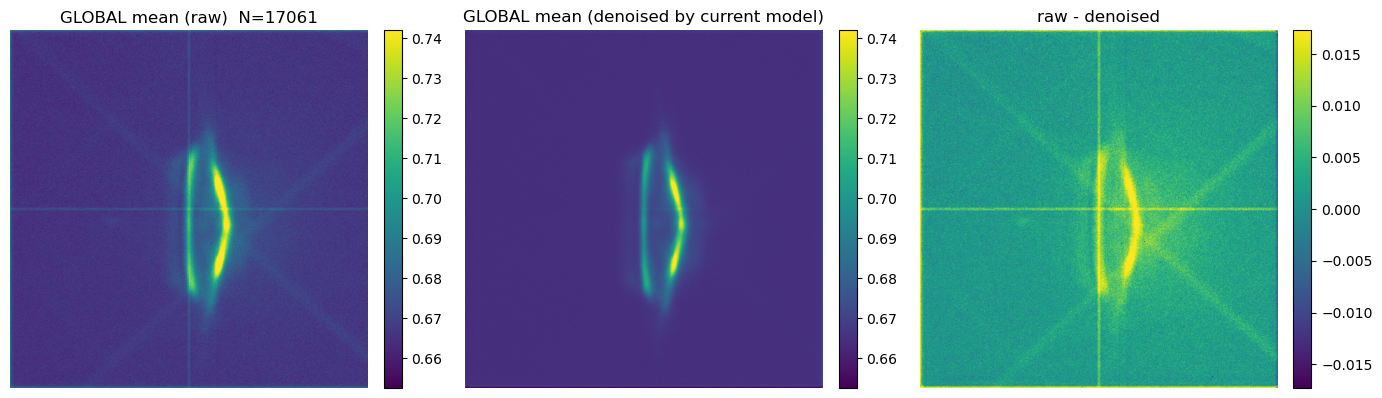

Done. Processed tiles: 17061/17061.  Elapsed: 2.24 min
mean_raw min/max: 0.6123724579811096 0.7912987431218802
mean_den min/max: 0.6192322081428404 0.7625248819951205


In [16]:
import time
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

assert "model" in globals(), "Need model"
assert "DEVICE" in globals(), "Need DEVICE"
assert "H5_PATH" in globals() and "X_KEY" in globals(), "Need H5_PATH, X_KEY"

model.eval()

# -------- USER CONFIG --------
BATCH_TILES = 64          # H100 可试 64/128（OOM 就降）
USE_AMP = True
USE_LOG = False

CMAP = "viridis"
VMIN_P = 0.1
VMAX_P = 99.7
DIFF_PCT = 99
# ----------------------------

def prep(img):
    return np.log1p(img) if USE_LOG else img

@torch.no_grad()
def infer_batch(arr_bhw: np.ndarray) -> np.ndarray:
    # arr_bhw: [B,H,W] float32
    tin = torch.from_numpy(arr_bhw[:, None]).to(DEVICE, non_blocking=True)  # [B,1,H,W]
    with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
        out = model(tin).float()  # [B,1,H,W]
    return out[:, 0].detach().cpu().numpy()  # [B,H,W]

t0 = time.time()

with h5py.File(H5_PATH, "r") as f:
    x = f[X_KEY]
    assert len(x.shape) == 4, f"Expected (H,W,detH,detW), got {x.shape}"
    H, W, detH, detW = x.shape
    total_tiles = H * W

    raw_sum = np.zeros((detH, detW), np.float64)
    den_sum = np.zeros((detH, detW), np.float64)
    n = 0

    buf = []
    pbar = tqdm(total=total_tiles, desc="Full pass denoise (all tiles)", unit="tile")

    for i in range(H):
        for j in range(W):
            tile = np.asarray(x[i, j], np.float32)   # (detH,detW)
            buf.append(tile)

            if len(buf) >= BATCH_TILES:
                arr = np.stack(buf, axis=0)  # [B,detH,detW]

                # accumulate raw
                raw_sum += arr.astype(np.float64).sum(axis=0)

                # denoise + accumulate
                out = infer_batch(arr)  # [B,detH,detW]
                den_sum += out.astype(np.float64).sum(axis=0)

                n += out.shape[0]
                buf = []
                pbar.update(out.shape[0])

    # flush last batch
    if len(buf) > 0:
        arr = np.stack(buf, axis=0)
        raw_sum += arr.astype(np.float64).sum(axis=0)
        out = infer_batch(arr)
        den_sum += out.astype(np.float64).sum(axis=0)
        n += out.shape[0]
        pbar.update(out.shape[0])

    pbar.close()

mean_raw = raw_sum / max(n, 1)
mean_den = den_sum / max(n, 1)
diff = mean_raw - mean_den

# ---- visualize ----
raw_show = prep(mean_raw)
den_show = prep(mean_den)

vmin = float(min(np.percentile(raw_show, VMIN_P), np.percentile(den_show, VMIN_P)))
vmax = float(max(np.percentile(raw_show, VMAX_P), np.percentile(den_show, VMAX_P)))

r = float(np.percentile(np.abs(diff), DIFF_PCT))
rvmin, rvmax = -r, r

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(raw_show, vmin=vmin, vmax=vmax, cmap=CMAP)
axes[0].set_title(f"GLOBAL mean (raw)  N={n}")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(den_show, vmin=vmin, vmax=vmax, cmap=CMAP)
axes[1].set_title("GLOBAL mean (denoised by current model)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(diff, vmin=rvmin, vmax=rvmax, cmap=CMAP)
axes[2].set_title("raw - denoised")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

print(f"Done. Processed tiles: {n}/{total_tiles}.  Elapsed: {(time.time()-t0)/60:.2f} min")
print("mean_raw min/max:", float(mean_raw.min()), float(mean_raw.max()))
print("mean_den min/max:", float(mean_den.min()), float(mean_den.max()))


These cells tier scan-grid tiles by signal strength (Otsu + percentiles), sample patches from tiers for Noise2Self, and train a U-Net with blob-protected masking to preserve diffraction spots.

Compute total_Real (top_mean):   0%|          | 0/17061 [00:00<?, ?tile/s]

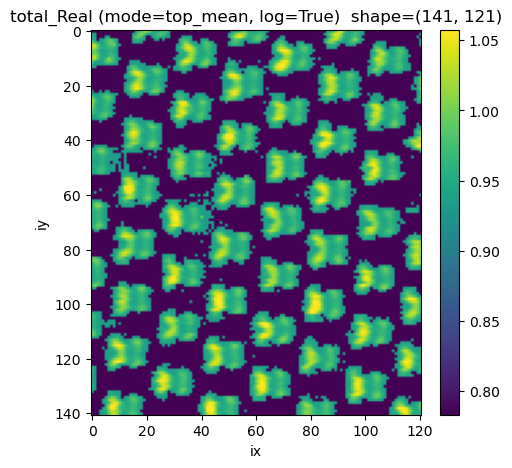

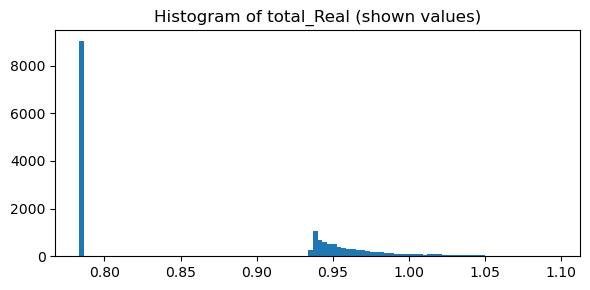

total_Real stats: min/median/max = 1.1888536214828491 1.192028284072876 1.994372010231018
KEEP_TOP=30%  threshold=1.58054  kept 5119/17061 tiles


In [15]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

assert "H5_PATH" in globals() and "X_KEY" in globals(), "Need H5_PATH and X_KEY"

# -------- USER CONFIG --------
# total_Real 的定义（你可以选一个更符合物理意义的）
SCORE_MODE = "top_mean"   # "sum" | "mean" | "p99" | "top_mean" | "energy"
TOP_P = 99.5              # top_mean: 取 >TOP_P percentile 的均值（更像“有没有亮斑/弧线”）
ENERGY_MED = 11           # energy: 用 median_filter 去背景（需要 scipy）
ENERGY_K = 3.0            # energy: 只统计高于 k*sigma 的正信号

# 可视化
CMAP = "viridis"
VMAX_P = 99.5             # total_Real 显示上限（percentile）
USE_LOG_TOTAL = True      # total_Real 动态范围很大时建议 True

# 筛选：保留强信号 top KEEP_TOP% 的点
KEEP_TOP = 30             # 例如保留 top 30% 强信号
# ----------------------------

# optional: for energy mode
try:
    from scipy.ndimage import median_filter
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

def robust_sigma(x):
    x = x[np.isfinite(x)]
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad + 1e-12

def score_frame(img: np.ndarray) -> float:
    I = img.astype(np.float32, copy=False)
    if SCORE_MODE == "sum":
        return float(I.sum())
    if SCORE_MODE == "mean":
        return float(I.mean())
    if SCORE_MODE == "p99":
        return float(np.percentile(I, 99.0))
    if SCORE_MODE == "top_mean":
        thr = np.percentile(I, TOP_P)
        top = I[I >= thr]
        return float(top.mean()) if top.size else float(thr)
    if SCORE_MODE == "energy":
        if not _HAS_SCIPY:
            raise RuntimeError("SCORE_MODE='energy' requires scipy.ndimage (median_filter).")
        base = median_filter(I, size=ENERGY_MED)
        hi = I - base
        sig = robust_sigma(hi)
        m = hi > (ENERGY_K * sig)
        return float(hi[m].sum()) if np.any(m) else 0.0
    raise ValueError("Unknown SCORE_MODE")

with h5py.File(H5_PATH, "r") as f:
    x = f[X_KEY]
    assert len(x.shape) == 4, f"Expected (H,W,detH,detW), got {x.shape}"
    H, W, detH, detW = x.shape

    total_Real = np.zeros((H, W), np.float32)

    pbar = tqdm(total=H*W, desc=f"Compute total_Real ({SCORE_MODE})", unit="tile")
    for iy in range(H):
        for ix in range(W):
            frame = np.asarray(x[iy, ix], np.float32)
            total_Real[iy, ix] = score_frame(frame)
            pbar.update(1)
    pbar.close()

# --- visualize ---
show = np.log1p(total_Real) if USE_LOG_TOTAL else total_Real
vmax = float(np.percentile(show, VMAX_P))

plt.figure(figsize=(6, 5))
plt.imshow(show, cmap=CMAP, vmax=vmax, origin="upper")
plt.title(f"total_Real (mode={SCORE_MODE}, log={USE_LOG_TOTAL})  shape={total_Real.shape}")
plt.xlabel("ix"); plt.ylabel("iy")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

plt.figure(figsize=(6, 3))
plt.hist(show.ravel(), bins=100)
plt.title("Histogram of total_Real (shown values)")
plt.tight_layout()
plt.show()

# --- selection mask (keep top KEEP_TOP%) ---
thr = np.percentile(total_Real, 100.0 - KEEP_TOP)
keep_mask = total_Real >= thr
keep_indices = np.argwhere(keep_mask)  # [[iy,ix], ...]

print("total_Real stats: min/median/max =", float(total_Real.min()), float(np.median(total_Real)), float(total_Real.max()))
print(f"KEEP_TOP={KEEP_TOP}%  threshold={thr:.6g}  kept {keep_indices.shape[0]}/{H*W} tiles")


看这种分布，采用构建分层采样索引 + 一个采样版 Dataset（直接替换 ds/dl）

Otsu thr = 0.7904162406921387  (log space)
bg tiles: 9032 / 17061
sig tiles: 8029 / 17061
thr_mid(sig) = 0.9451049566268921  thr_high(sig) = 0.9729807376861572
tiers: bg/ mid / high = 9032 2410 2409


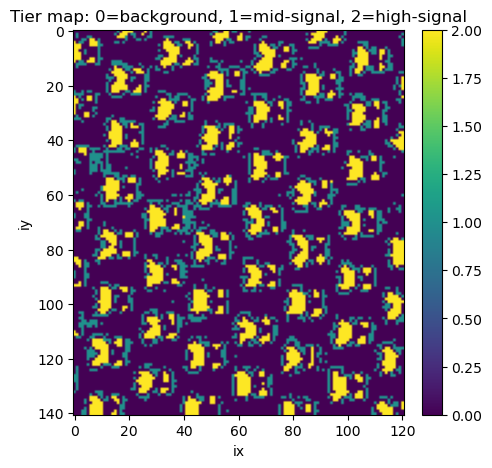

In [16]:
import numpy as np
import matplotlib.pyplot as plt

assert "total_Real" in globals(), "Need total_Real"

# -------- USER CONFIG --------
USE_LOG_FOR_THRESH = True     # 用 log1p(total_Real) 做阈值更稳
SIG_P_HIGH = 70               # 在 signal 群内部，>=p70 算 high
SIG_P_MID  = 30               # 在 signal 群内部，<=p30 算 mid（中间就是 mid）
# ----------------------------

x = np.log1p(total_Real) if USE_LOG_FOR_THRESH else total_Real
vals = x.ravel()

# ---- Otsu threshold in 1D (numpy only) ----
hist, bin_edges = np.histogram(vals, bins=512)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

w0 = np.cumsum(hist)
w1 = np.cumsum(hist[::-1])[::-1]
mu0 = np.cumsum(hist * bin_centers) / np.maximum(w0, 1e-12)
mu1 = (np.cumsum((hist * bin_centers)[::-1]) / np.maximum(w1[::-1], 1e-12))[::-1]

between = w0[:-1] * w1[1:] * (mu0[:-1] - mu1[1:])**2
k = np.argmax(between)
thr_otsu = bin_centers[k]

bg_mask = x <= thr_otsu
sig_mask = ~bg_mask

print("Otsu thr =", float(thr_otsu), " (log space)" if USE_LOG_FOR_THRESH else "")
print("bg tiles:", int(bg_mask.sum()), "/", bg_mask.size)
print("sig tiles:", int(sig_mask.sum()), "/", sig_mask.size)

# ---- split signal into mid/high inside sig only ----
sig_vals = x[sig_mask]
thr_mid  = np.percentile(sig_vals, SIG_P_MID)
thr_high = np.percentile(sig_vals, SIG_P_HIGH)

mid_mask  = sig_mask & (x <= thr_mid)
high_mask = sig_mask & (x >= thr_high)
lo_mask   = bg_mask  # background as its own tier

print("thr_mid(sig) =", float(thr_mid), " thr_high(sig) =", float(thr_high))
print("tiers: bg/ mid / high =", int(lo_mask.sum()), int(mid_mask.sum()), int(high_mask.sum()))

# ---- quick visualization: show tiers ----
tier_img = np.zeros_like(total_Real, dtype=np.int8)
tier_img[lo_mask] = 0
tier_img[mid_mask] = 1
tier_img[high_mask] = 2

plt.figure(figsize=(6,5))
plt.imshow(tier_img, origin="upper")
plt.title("Tier map: 0=background, 1=mid-signal, 2=high-signal")
plt.xlabel("ix"); plt.ylabel("iy")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()


In [17]:
import numpy as np
import h5py
import torch
from torch.utils.data import Dataset, DataLoader

assert "H5_PATH" in globals() and "X_KEY" in globals(), "Need H5_PATH and X_KEY"

# -------- USER CONFIG --------
# 采样概率（建议：让训练主要看 signal，但保留少量背景）
PROB_BG, PROB_MID, PROB_HIGH = 0.10, 0.20, 0.70   # 你也可以 0.05/0.25/0.70

# 数据集/训练相关
CROP = 256
SAMPLES_PER_EPOCH = 8000
MASK_RATIO = 0.03
BATCH = 8
NUM_WORKERS = 4

# blob 保护（沿用方案二）
BLOB_K = 8.0
BLOB_MED = 11
BLOB_AMIN = 3
BLOB_AMAX = 300
BLOB_DILATE = 1
FILL_MODE = "neighbor"
# ----------------------------

# ---- tier masks: use existing (bg_mask/mid_mask/high_mask) or derive from tier_img ----
if "bg_mask" in globals() and "mid_mask" in globals() and "high_mask" in globals():
    bg_mask   = bg_mask.astype(bool)
    mid_mask  = mid_mask.astype(bool)
    high_mask = high_mask.astype(bool)
elif "tier_img" in globals():
    tier_img = np.asarray(tier_img)
    bg_mask   = (tier_img == 0)
    mid_mask  = (tier_img == 1)
    high_mask = (tier_img == 2)
else:
    raise AssertionError("Need (bg_mask, mid_mask, high_mask) or tier_img from the Otsu tier cell.")

# ---- build tier indices ----
bg_idx   = np.argwhere(bg_mask)
mid_idx  = np.argwhere(mid_mask)
high_idx = np.argwhere(high_mask)

print("tiers: bg / mid / high =", len(bg_idx), len(mid_idx), len(high_idx), " total =", bg_mask.size)

tier_probs = np.array([PROB_BG, PROB_MID, PROB_HIGH], dtype=np.float64)
tier_probs = tier_probs / tier_probs.sum()

rng_global = np.random.default_rng(0)

def pick_tile_index():
    tier = rng_global.choice(3, p=tier_probs)
    if tier == 0:
        iy, ix = bg_idx[rng_global.integers(len(bg_idx))]
    elif tier == 1:
        iy, ix = mid_idx[rng_global.integers(len(mid_idx))]
    else:
        iy, ix = high_idx[rng_global.integers(len(high_idx))]
    return int(iy), int(ix)

# --- deps for blob detection (same as before) ---
try:
    from scipy.ndimage import median_filter, label, binary_dilation
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False
    print("[WARN] scipy.ndimage not available -> blob protection disabled.")

def robust_sigma(x):
    x = x[np.isfinite(x)]
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad + 1e-12

def blob_mask_from_patch(patch, k=8.0, med_size=11, amin=3, amax=300, dilate=1):
    if not _HAS_SCIPY:
        return np.zeros_like(patch, dtype=bool)
    base = median_filter(patch, size=med_size)
    hi = patch - base
    sig = robust_sigma(hi)
    m0 = hi > (k * sig)
    lab, nlab = label(m0)
    if nlab == 0:
        return m0
    counts = np.bincount(lab.ravel())
    keep_ids = np.where((counts >= amin) & (counts <= amax))[0]
    keep_ids = keep_ids[keep_ids != 0]
    m = np.isin(lab, keep_ids)
    if dilate and dilate > 0:
        m = binary_dilation(m, iterations=int(dilate))
    return m

class H5N2S_Stratified(Dataset):
    """
    N2S + blob protection, tile sampling from Otsu tiers.
    Returns: inp, tgt, lmask, blobmask   (each [1,crop,crop])
    """
    def __init__(self, h5_path, x_key, mask_key=None, crop=256,
                 samples_per_epoch=4000, mask_ratio=0.03,
                 blob_k=8.0, blob_med=11, blob_amin=3, blob_amax=300, blob_dilate=1,
                 fill_mode="neighbor"):
        self.h5_path = str(h5_path)
        self.x_key = x_key
        self.mask_key = mask_key
        self.crop = int(crop)
        self.spe = int(samples_per_epoch)
        self.mask_ratio = float(mask_ratio)
        self.blob_k = float(blob_k)
        self.blob_med = int(blob_med)
        self.blob_amin = int(blob_amin)
        self.blob_amax = int(blob_amax)
        self.blob_dilate = int(blob_dilate)
        assert fill_mode in ("zero", "neighbor")
        self.fill_mode = fill_mode

        with h5py.File(self.h5_path, "r") as f:
            x = f[self.x_key]
            self.Hg, self.Wg, self.H, self.W = x.shape  # gridH, gridW, detH, detW
            if self.H < self.crop or self.W < self.crop:
                raise ValueError(f"crop={self.crop} larger than image {self.H}x{self.W}")

    def __len__(self):
        return self.spe

    def __getitem__(self, idx):
        iy, ix = pick_tile_index()

        y0 = np.random.randint(0, self.H - self.crop + 1)
        x0 = np.random.randint(0, self.W - self.crop + 1)
        ys = slice(y0, y0 + self.crop)
        xs = slice(x0, x0 + self.crop)

        with h5py.File(self.h5_path, "r") as f:
            x = f[self.x_key]
            patch = np.asarray(x[iy, ix, ys, xs], np.float32)
            if self.mask_key is None:
                vmask = np.ones((self.crop, self.crop), bool)
            else:
                m = f[self.mask_key]
                vmask = np.asarray(m[iy, ix, ys, xs], bool)

        bmask = blob_mask_from_patch(
            patch,
            k=self.blob_k, med_size=self.blob_med,
            amin=self.blob_amin, amax=self.blob_amax,
            dilate=self.blob_dilate
        ) & vmask

        pick = (np.random.rand(*patch.shape) < self.mask_ratio) & vmask & (~bmask)

        inp = patch.copy()
        if self.fill_mode == "zero":
            inp[pick] = 0.0
        else:
            r = 2
            yy, xx = np.where(pick)
            if len(yy) > 0:
                dy = np.random.randint(-r, r+1, size=len(yy))
                dx = np.random.randint(-r, r+1, size=len(xx))
                yy2 = np.clip(yy + dy, 0, patch.shape[0]-1)
                xx2 = np.clip(xx + dx, 0, patch.shape[1]-1)
                inp[yy, xx] = patch[yy2, xx2]

        tgt = patch
        lmask = pick.astype(np.float32)

        return (
            torch.from_numpy(inp[None]),
            torch.from_numpy(tgt[None]),
            torch.from_numpy(lmask[None]),
            torch.from_numpy(bmask.astype(np.float32)[None]),
        )

# ---- build ds/dl ----
MASK_KEY = globals().get("MASK_KEY", None)

ds = H5N2S_Stratified(
    H5_PATH, X_KEY, mask_key=MASK_KEY,
    crop=CROP, samples_per_epoch=SAMPLES_PER_EPOCH, mask_ratio=MASK_RATIO,
    blob_k=BLOB_K, blob_med=BLOB_MED, blob_amin=BLOB_AMIN, blob_amax=BLOB_AMAX, blob_dilate=BLOB_DILATE,
    fill_mode=FILL_MODE,
)

dl = DataLoader(ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS,
                pin_memory=True, drop_last=True)

b = next(iter(dl))
print("Stratified dataset ready. Batch shapes:",
      b[0].shape, b[1].shape, b[2].shape, b[3].shape)


tiers: bg / mid / high = 9032 2410 2409  total = 17061
Stratified dataset ready. Batch shapes: torch.Size([8, 1, 256, 256]) torch.Size([8, 1, 256, 256]) torch.Size([8, 1, 256, 256]) torch.Size([8, 1, 256, 256])


In [18]:
import time
import torch
from torch.cuda.amp import autocast, GradScaler

assert "model" in globals()
assert "dl" in globals()
assert "DEVICE" in globals()
assert "OUT_DIR" in globals()

# -------- USER CONFIG --------
EPOCHS = 5
LR = 2e-4
LOG_EVERY = 50
CKPT_PATH = OUT_DIR / "n2s_unet_small_stratified.pt"
# ----------------------------

opt = torch.optim.AdamW(model.parameters(), lr=LR)
scaler = GradScaler(enabled=(DEVICE.type == "cuda"))

def masked_mse(pred, tgt, lmask, eps=1e-6):
    num = ((pred - tgt) ** 2 * lmask).sum()
    den = lmask.sum().clamp_min(eps)
    return num / den

def save_ckpt():
    torch.save({"model": model.state_dict(), "opt": opt.state_dict()}, CKPT_PATH)

def try_load_ckpt():
    if CKPT_PATH.exists():
        ck = torch.load(CKPT_PATH, map_location="cpu")
        model.load_state_dict(ck["model"])
        opt.load_state_dict(ck["opt"])
        print("Loaded ckpt:", CKPT_PATH)

try_load_ckpt()

model.train()
t0 = time.time()
step = 0
run = 0.0

for ep in range(1, EPOCHS + 1):
    for batch in dl:
        # batch: (inp, tgt, lmask, blobmask)
        inp, tgt, lmask, blobmask = batch

        inp = inp.to(DEVICE, non_blocking=True)
        tgt = tgt.to(DEVICE, non_blocking=True)
        lmask = lmask.to(DEVICE, non_blocking=True)
        blobmask = blobmask.to(DEVICE, non_blocking=True)

        # ✅ 不在 blob 区域计算loss（更保信号）
        lmask_eff = lmask * (1.0 - blobmask)

        opt.zero_grad(set_to_none=True)
        with autocast(enabled=(DEVICE.type == "cuda")):
            pred = model(inp)
            loss = masked_mse(pred, tgt, lmask_eff)

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        run += loss.item()
        step += 1
        if step % LOG_EVERY == 0:
            print(f"ep {ep:02d} step {step:06d}  loss={run/LOG_EVERY:.6g}  elapsed={(time.time()-t0)/60:.1f} min")
            run = 0.0

    save_ckpt()
    print(f"[epoch {ep}] saved -> {CKPT_PATH}")


/var/tmp/ipykernel_86698/4005079866.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == "cuda"))
/var/tmp/ipykernel_86698/4005079866.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == "cuda")):


ep 01 step 000050  loss=0.030103  elapsed=0.1 min
ep 01 step 000100  loss=0.0291592  elapsed=0.1 min
ep 01 step 000150  loss=0.028762  elapsed=0.2 min
ep 01 step 000200  loss=0.0289414  elapsed=0.2 min
ep 01 step 000250  loss=0.0288791  elapsed=0.3 min
ep 01 step 000300  loss=0.0288694  elapsed=0.4 min
ep 01 step 000350  loss=0.0287938  elapsed=0.4 min
ep 01 step 000400  loss=0.0288972  elapsed=0.5 min
ep 01 step 000450  loss=0.028772  elapsed=0.5 min
ep 01 step 000500  loss=0.0284887  elapsed=0.6 min
ep 01 step 000550  loss=0.0287244  elapsed=0.7 min
ep 01 step 000600  loss=0.0287623  elapsed=0.7 min
ep 01 step 000650  loss=0.0285591  elapsed=0.8 min
ep 01 step 000700  loss=0.0286538  elapsed=0.8 min
ep 01 step 000750  loss=0.0287498  elapsed=0.9 min
ep 01 step 000800  loss=0.0286281  elapsed=1.0 min
ep 01 step 000850  loss=0.0286147  elapsed=1.0 min
ep 01 step 000900  loss=0.0289766  elapsed=1.1 min
ep 01 step 000950  loss=0.0287667  elapsed=1.1 min
ep 01 step 001000  loss=0.0288152 

/var/tmp/ipykernel_86698/228056555.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):


[sample 0] ds_idx=6724  raw shape=(256, 256) dtype=float32
  pick(lmask) pixels: 1855 / 65536  (2.83%)
  blobmask pixels    : 4291 / 65536  (6.55%)
  overlap(pick&blob) : 0  (should be near 0 if (~bmask) used)


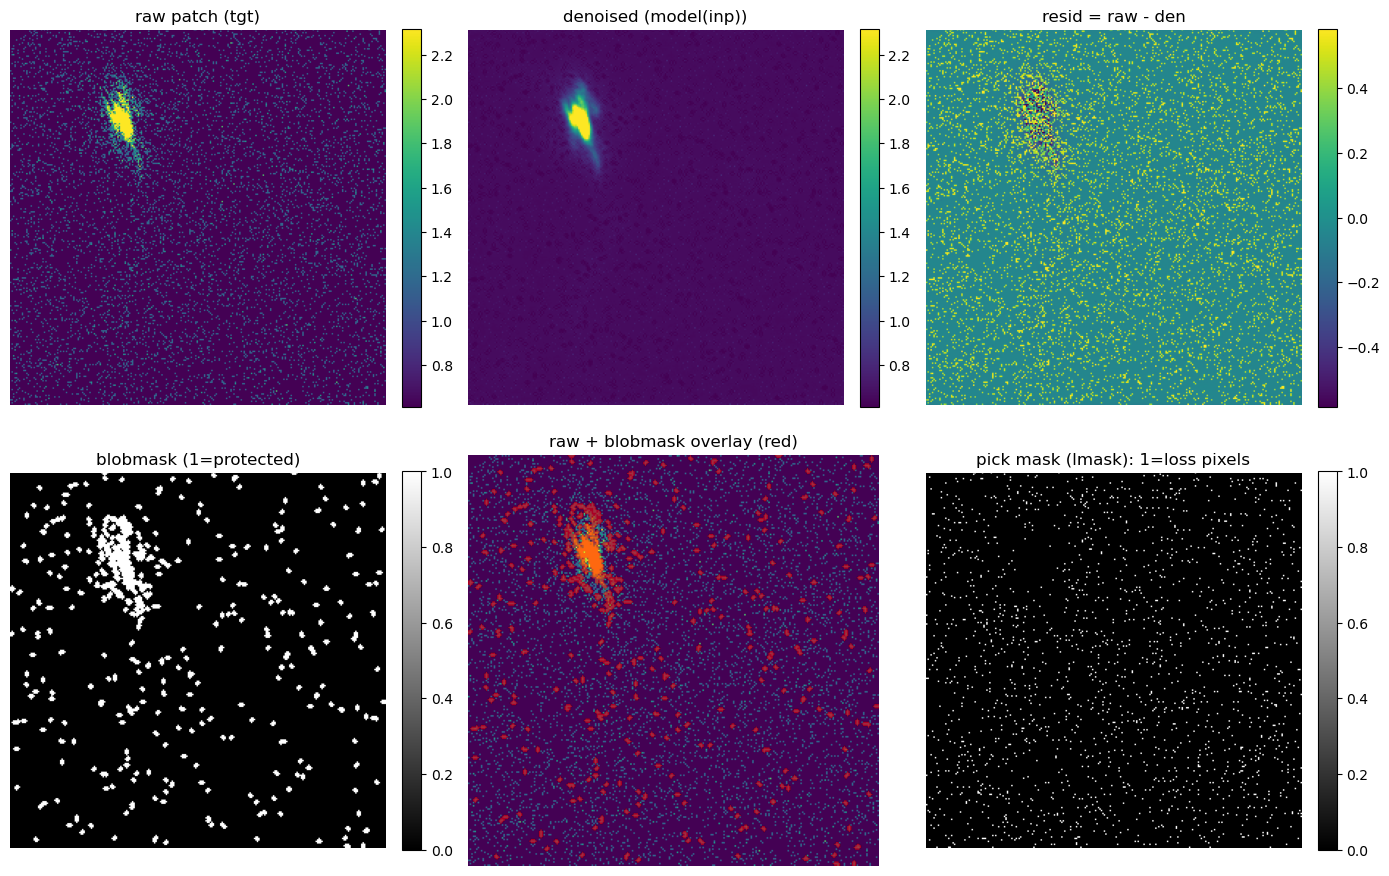

In [29]:
# =========================
# Sanity: show raw + blobmask + pick + denoised + resid
# =========================
import numpy as np
import matplotlib.pyplot as plt
import torch

assert "ds" in globals(), "Need ds built first."
assert "model" in globals(), "Need trained model."
assert "DEVICE" in globals(), "Need DEVICE."

model.eval()

# -------- USER CONFIG --------
SEED = 192398
N_TRIES = 1        # 看几张就改 3/5
VMIN_P = 0.1       # raw/den 显示下限 percentile
VMAX_P = 99.7      # raw/den 显示上限 percentile
P_RES  = 99        # resid 用 abs(resid) 的 percentile 定对称范围
ALPHA  = 0.55      # overlay 透明度
USE_AMP = True     # 推理加速（H100 推荐 True）
CMAP = "viridis"
# ----------------------------

rng = np.random.default_rng(SEED)

def show_one(sample_id=0):
    idx = int(rng.integers(0, len(ds)))
    inp_t, tgt_t, lmask_t, blob_t = ds[idx]  # each [1,crop,crop] torch tensor (CPU)

    # to numpy
    raw  = tgt_t.numpy()[0]                    # [H,W]
    inp  = inp_t.numpy()[0]
    pick = (lmask_t.numpy()[0] > 0)            # True=算loss的位置
    bmask = (blob_t.numpy()[0] > 0)            # True=blob区域

    # ---- inference (use inp_t, not raw) ----
    with torch.no_grad():
        tin = inp_t[None].to(DEVICE, non_blocking=True)  # [1,1,H,W]
        with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
            den_t = model(tin).float().cpu()[0, 0]       # [H,W]
    den = den_t.numpy()
    resid = raw - den

    # ---- stats ----
    print(f"[sample {sample_id}] ds_idx={idx}  raw shape={raw.shape} dtype={raw.dtype}")
    print(f"  pick(lmask) pixels: {pick.sum()} / {pick.size}  ({pick.mean()*100:.2f}%)")
    print(f"  blobmask pixels    : {bmask.sum()} / {bmask.size}  ({bmask.mean()*100:.2f}%)")
    print(f"  overlap(pick&blob) : {(pick & bmask).sum()}  (should be near 0 if (~bmask) used)")

    # ---- color ranges ----
    # raw/den 同一色标：用 raw 的百分位更稳定
    vmin = float(np.percentile(raw, VMIN_P))
    vmax = float(np.percentile(raw, VMAX_P))

    # resid 对称色标
    r = float(np.percentile(np.abs(resid), P_RES))
    rvmin, rvmax = -r, r

    # ---- plot 2x3 ----
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))

    im0 = axes[0,0].imshow(raw, vmin=vmin, vmax=vmax, cmap=CMAP)
    axes[0,0].set_title("raw patch (tgt)")
    axes[0,0].axis("off")
    plt.colorbar(im0, ax=axes[0,0], fraction=0.046, pad=0.04)

    im1 = axes[0,1].imshow(den, vmin=vmin, vmax=vmax, cmap=CMAP)
    axes[0,1].set_title("denoised (model(inp))")
    axes[0,1].axis("off")
    plt.colorbar(im1, ax=axes[0,1], fraction=0.046, pad=0.04)

    im2 = axes[0,2].imshow(resid, vmin=rvmin, vmax=rvmax, cmap=CMAP)
    axes[0,2].set_title("resid = raw - den")
    axes[0,2].axis("off")
    plt.colorbar(im2, ax=axes[0,2], fraction=0.046, pad=0.04)

    # blobmask (gray)
    im3 = axes[1,0].imshow(bmask.astype(np.float32), cmap="gray", vmin=0, vmax=1)
    axes[1,0].set_title("blobmask (1=protected)")
    axes[1,0].axis("off")
    plt.colorbar(im3, ax=axes[1,0], fraction=0.046, pad=0.04)

    # overlay: raw + blobmask red
    axes[1,1].imshow(raw, vmin=vmin, vmax=vmax, cmap=CMAP)
    overlay = np.zeros((*raw.shape, 4), dtype=np.float32)
    overlay[..., 0] = bmask.astype(np.float32)               # R
    overlay[..., 3] = bmask.astype(np.float32) * float(ALPHA)
    axes[1,1].imshow(overlay)
    axes[1,1].set_title("raw + blobmask overlay (red)")
    axes[1,1].axis("off")

    # pick mask
    im5 = axes[1,2].imshow(pick.astype(np.float32), cmap="gray", vmin=0, vmax=1)
    axes[1,2].set_title("pick mask (lmask): 1=loss pixels")
    axes[1,2].axis("off")
    plt.colorbar(im5, ax=axes[1,2], fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.show()

for k in range(N_TRIES):
    show_one(k)
